# Lab 1: Working with data

## Data processing with Pandas

In [42]:
# Load data
import pandas as pd


# Load the dataset in Excel format into a pandas DataFrame
grade_df = pd.read_excel('../data/final_grades.xlsx')

In [43]:
# View the first 10 rows of the DataFrame
grade_df.head(10)
# Make descriptive statistics of the DataFrame
grade_df.describe()

,Grade
count,1230.000000
mean,6.238154
std,1.605444
min,2.290000
25%,5.040000
50%,6.230000
75%,7.400000
max,10.000000


In [44]:
# Check if there are any missing values in the DataFrame
missing_values = grade_df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Major    0
Grade    0
dtype: int64


In [45]:
# Get the value of the 'Major' 
major_names = grade_df['Major'].unique()
print(major_names)

<StringArray>
[ 'cdt', 'cnot', 'khhh', 'ckdl',  'ctm', 'cnhh', 'cnmt', 'ktck',  'vsh',
  'tdh', 'kttt', 'cnxd',  'ddt', 'cntt',  'kte', 'ckts', 'cnnl', 'khmt',
 'cbts', 'ttql']
Length: 20, dtype: str


In [46]:
# Filter the DF to include only students with major 'khmt', 'cntt' or 'ttql'

it_majors = ['khmt', 'cntt', 'ttql']
it_students_df = grade_df[grade_df['Major'].isin(it_majors)]
print(f'#IT students/#Total: {len(it_students_df)}/{len(grade_df)}')


#IT students/#Total: 338/1230


In [47]:
# Add a new column 'Result' to note "Pass" if grade >= 5, otherwise "Fail"
grade_df['Result'] = grade_df['Grade'].apply(lambda x: 'Pass' if x >= 5 else 'Fail')
# Display the first 10 rows of the updated DataFrame
grade_df.head(10)


,Major,Grade,Result
0,cdt,8.21,Pass
1,cdt,9.25,Pass
2,cdt,8.50,Pass
3,cdt,3.90,Fail
4,cdt,7.50,Pass
5,cdt,7.25,Pass
6,cdt,7.06,Pass
7,cdt,7.83,Pass
8,cdt,6.40,Pass
9,cdt,6.23,Pass


In [48]:
# Add a new colum 'MajorGroup' to group majors into 'IT' and 'Non-IT'
it_majors = ['khmt', 'cntt', 'ttql']

grade_df['MajorGroup'] = \
    grade_df['Major'].apply(lambda x: 'IT' if x in it_majors else 'Non-IT')

# Display the first 10 rows of the updated DataFrame
grade_df.head(10)
# Filter all rows with 'MajorGroup' = 'IT'
it_students_df = grade_df[grade_df['MajorGroup'] == 'IT']
it_students_df.head(-10)

,Major,Grade,Result,MajorGroup
376,cntt,6.08,Pass,IT
377,cntt,7.31,Pass,IT
379,cntt,5.56,Pass,IT
380,cntt,5.60,Pass,IT
381,cntt,5.08,Pass,IT
...,...,...,...,...
1215,ttql,4.52,Fail,IT
1216,ttql,5.13,Pass,IT
1217,ttql,8.75,Pass,IT
1218,ttql,6.69,Pass,IT


In [49]:
# Save the updated DataFrame to a new csv file
grade_df.to_csv('../data/final_grades_updated.csv',index=False)

## Visualization with Matplotlib

In [50]:
# install matplotlib (if not installed)
# !pip install matplotlib

In [51]:
import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib version:", matplotlib.__version__)

Matplotlib version: 3.11.2


In [52]:
# Re display the first 5 rows of the DataFrame to check the data
grade_df.head()

,Major,Grade,Result,MajorGroup
0,cdt,8.21,Pass,Non-IT
1,cdt,9.25,Pass,Non-IT
2,cdt,8.50,Pass,Non-IT
3,cdt,3.90,Fail,Non-IT
4,cdt,7.50,Pass,Non-IT


In [53]:
# Computer basic statistics of the data to show on the plot
total_students = len(grade_df)
print(f'Total students: {total_students}')
# Calculate the mean grade
mean_grade = grade_df['Grade'].mean()
print(f'Mean grade: {mean_grade:.2f}')
# Get the median grade
median_grade = grade_df['Grade'].median()
print(f'Median grade: {median_grade:.2f}')
# Calculate the standard deviation of the grades
std = grade_df['Grade'].std()
# Get the minimum and maximum grades
min_grade = grade_df['Grade'].min()
print(f'Minimum grade: {min_grade:.2f}')
max_grade = grade_df['Grade'].max()
print(f'Maximum grade: {max_grade:.2f}')

Total students: 1230
Mean grade: 6.24
Median grade: 6.23
Minimum grade: 2.29
Maximum grade: 10.00


In [54]:
import numpy as np

# Create historgram bins of the grades with interval of 0.5
bins = np.arange(0, 10.5, 0.5)
print(bins)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]


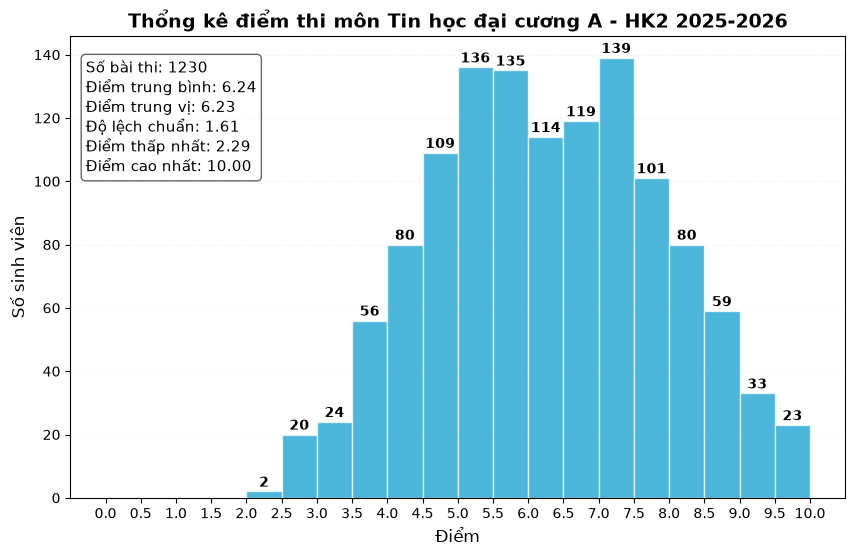

In [59]:
# Crate a histogram of the grades
plt.figure(figsize=(10, 6)) # Set the figure size

counts, edges, patches = plt.hist(grade_df['Grade'], # data to plot
bins=bins,                  # bins for the histogram
color='#0099cc',            # color of the bars
edgecolor='white',
alpha=0.7)              # transparency of the bars

# Add title and labels to the plot
plt.title('PHỔ ĐIỂM BÀI THI CUỐI KỲ THĐC A - TẤT CẢ CÁC NGÀNH', fontsize=16)
plt.xlabel('Điểm', fontsize=14)
plt.ylabel('Số sinh viên', fontsize=14)

# Add count value on top of each bar
for count, edge_left, edge_right in zip(counts, edges[:-1], edges[1:]):
    if count > 0:  # only add text for bars with count > 0
        # calculate the position for the text
        x_pos = (edge_left + edge_right) / 2
        y_pos = count + 0.5  # position the text slightly above the bar
        # print the count value on top of the bar
        plt.text(x_pos, y_pos, str(int(count)), 
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black')

# Add statistics text box to the plot
stats_text = "{}{}\n{}{:.2f}\n{}{:.2f} \
\n{}{:.2f}\n{}{:.2f}\n{}{:.2f}".format("Số bài thi: ", total_students,
                                                    "Điểm trung bình: ", mean_grade,
                                                    "Điểm trung vị: ",  median_grade,
                                                    "Độ lệch chuẩn: ",std,
                                                    "Điểm thấp nhất: ",min_grade,
                                                    "Điểm cao nhất: " ,max_grade )


plt.gca().text(
    0.02, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)


bin_interval = 0.5
bins = np.arange(0, 10 + bin_interval, bin_interval)
bin_labels = [str(bins[i]) + '-' + str(bins[i+1]) for i in range(len(bins)-1)]

# Customize the chart
plt.title("Thổng kê điểm thi môn Tin học đại cương A - HK2 2025-2026", fontsize=14, weight='bold')
plt.xlabel("Điểm", fontsize=12)
plt.ylabel("Số sinh viên", fontsize=12)
# plt.xticks(bin_labels, rotation=90)
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.1)

# Display the plot 
# plt.tight_layout()
plt.savefig('THDC-Grade-Stats.png') 
plt.show()

## So sánh phổ điểm của nhóm ngành CNTT vs ngành khác (stacked histogram)

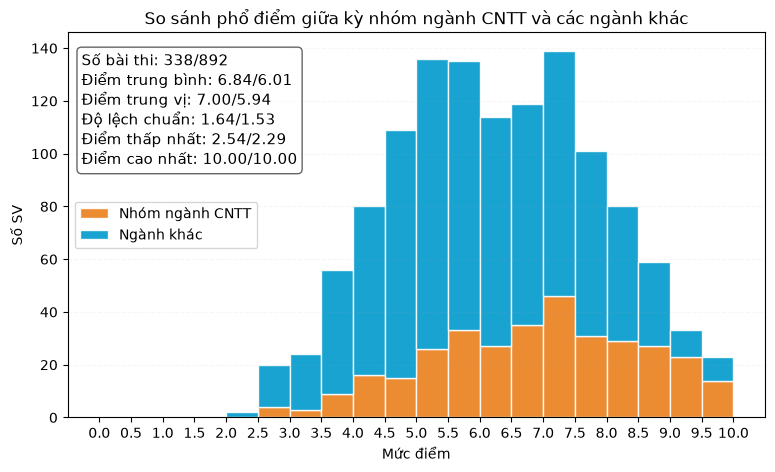

In [60]:
# Filter grades of IT group
grades_cntt = grade_df[grade_df['MajorGroup'] == 'IT']
# Filter grades of Non-IT group
grades_others = grade_df[grade_df['MajorGroup'] == 'Non-IT']

data1 = grades_cntt['Grade'].values
data2 = grades_others['Grade'].values

plt.figure(figsize=(9, 5))
bins = np.arange(0, 10 + 0.25, 0.5)
combined_data = np.hstack((data1, data2))
counts, bins = np.histogram(combined_data, bins=bins) # grade interval = 0.5

# Plot the histograms using the same bins
plt.hist([data1, data2], stacked=True, bins=bins, alpha=0.9, 
         label=['Nhóm ngành CNTT','Ngành khác'], color=['#ea801c', '#0099cc'], edgecolor='white')

# Compute basic statistics
# IT major
total_students_it = len(grades_cntt)
mean_grade_it = grades_cntt['Grade'].mean()
median_grade_it = grades_cntt['Grade'].median()
std_it = grades_cntt['Grade'].std()
min_grade_it = grades_cntt['Grade'].min()
max_grade_it = grades_cntt['Grade'].max()

# Non IT major
total_students_others = len(grades_others)
mean_grade_others = grades_others['Grade'].mean()
median_grade_others = grades_others['Grade'].median()
std_others = grades_others['Grade'].std()
min_grade_others = grades_others['Grade'].min()
max_grade_others = grades_others['Grade'].max()

# Annotate statistics at top-left 
stats_text = "{}{}/{}\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f} \
\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f}".format("Số bài thi: ", total_students_it, total_students_others,
                                                    "Điểm trung bình: ", mean_grade_it, mean_grade_others,
                                                    "Điểm trung vị: ",  median_grade_it, median_grade_others,
                                                    "Độ lệch chuẩn: ",std_it, std_others,
                                                    "Điểm thấp nhất: ",min_grade_it, min_grade_others,
                                                    "Điểm cao nhất: " ,max_grade_it, max_grade_others)
plt.gca().text(
    0.02, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

plt.xlabel('Mức điểm')
plt.ylabel('Số SV')
plt.title('So sánh phổ điểm giữa kỳ nhóm ngành CNTT và các ngành khác')
plt.xticks(bins)
plt.legend()
#plt.grid(True, linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.legend(loc='center left')
# Save the chart to file
plt.savefig('grade-by-major.pdf')
# Show the plot
plt.show()